# Introduction to Data Analysis

In this section, we import essential libraries that will help us explore and analyze the dataset.
- `pandas` for data manipulation.
- `matplotlib` & `seaborn` for data visualization.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Let's load the **120 Years of Olympic History - Athletes and Results** dataset. Since it's stored online, we use `pd.read_csv()` to read it directly from the URL.

In [3]:
url = "https://raw.githubusercontent.com/cstorm125/information_value/refs/heads/master/data/120-years-of-olympic-history-athletes-and-results/athlete_events.csv"
df = pd.read_csv(url)

Understanding the structure of the dataset is key before diving into analysis. Let's:
- Check the data types of each column.
- Count non-null values.
- Look at the first few rows.

In [3]:
print("Dataset Overview:")
print(df.info())
print("\nFirst 5 rows:")
print(df.head())

Dataset Overview:
<class 'pandas.DataFrame'>
RangeIndex: 271116 entries, 0 to 271115
Data columns (total 15 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   ID      271116 non-null  int64  
 1   Name    271116 non-null  str    
 2   Sex     271116 non-null  str    
 3   Age     261642 non-null  float64
 4   Height  210945 non-null  float64
 5   Weight  208241 non-null  float64
 6   Team    271116 non-null  str    
 7   NOC     271116 non-null  str    
 8   Games   271116 non-null  str    
 9   Year    271116 non-null  int64  
 10  Season  271116 non-null  str    
 11  City    271116 non-null  str    
 12  Sport   271116 non-null  str    
 13  Event   271116 non-null  str    
 14  Medal   39783 non-null   str    
dtypes: float64(3), int64(2), str(10)
memory usage: 56.6 MB
None

First 5 rows:
   ID                      Name Sex   Age  Height  Weight            Team  \
0   1                 A Dijiang   M  24.0   180.0    80.0           China   
1 

A quick glance at summary statistics helps us understand numerical distributions, potential outliers, and missing values.

In [11]:
print("\nSummary Statistics:")
print(df.describe())
print("\nMissing Values:")
print(df.isnull().sum())


Summary Statistics:
                  ID            Age        Height         Weight  \
count  271116.000000  261642.000000  271116.00000  271116.000000   
mean    68248.954396      25.556898     175.26374      70.539500   
std     39022.286345       6.393561       9.27917      12.578184   
min         1.000000      10.000000     127.00000      25.000000   
25%     34643.000000      21.000000     170.00000      63.000000   
50%     68205.000000      24.000000     175.00000      70.000000   
75%    102097.250000      28.000000     180.00000      75.000000   
max    135571.000000      97.000000     226.00000     214.000000   

                Year  
count  271116.000000  
mean     1978.378480  
std        29.877632  
min      1896.000000  
25%      1960.000000  
50%      1988.000000  
75%      2002.000000  
max      2016.000000  

Missing Values:
ID             0
Name           0
Sex            0
Age         9474
Height         0
Weight         0
Team           0
NOC            0
Games 

Missing values can affect our analysis. Here, we handle missing values in the 'Height' and 'Weight' columns by filling them with the median values.

In [6]:
df['Height'] = df['Height'].fillna(df['Height'].median())
df['Weight'] = df['Weight'].fillna(df['Weight'].median())

Grouping and counting occurrences of sports helps us understand which events are most frequent in the dataset.

In [7]:
print("\nTop 5 Most Frequent Sports:")
print(df['Sport'].value_counts().head(5))


Top 5 Most Frequent Sports:
Sport
Athletics     38624
Gymnastics    26707
Swimming      23195
Shooting      11448
Cycling       10859
Name: count, dtype: int64


A histogram is a great way to visualize the distribution of ages among Olympic athletes.

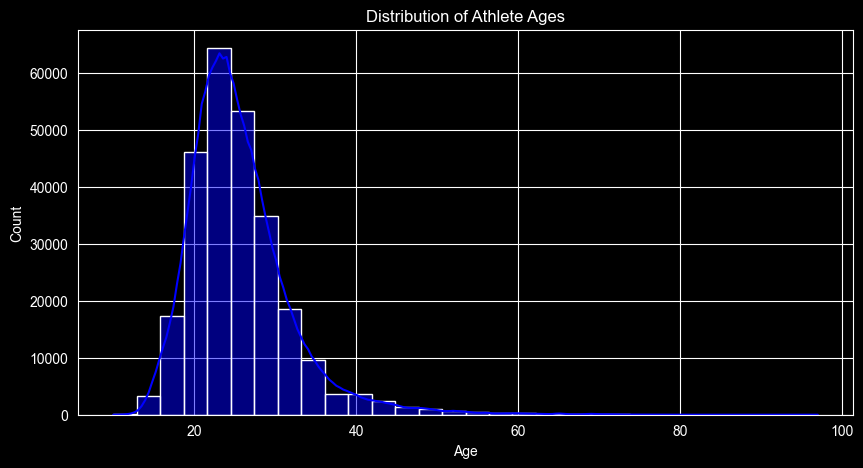

In [8]:
plt.figure(figsize=(10,5))
sns.histplot(df['Age'].dropna(), bins=30, kde=True, color='blue')
plt.title('Distribution of Athlete Ages')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

By grouping the data by `Sport` and computing the mean age, we can determine the age distribution across different sports.

In [9]:
sport_ages = df.groupby('Sport')['Age'].mean().sort_values(ascending=False)
print("\nTop 5 Sports by Average Athlete Age:")
print(sport_ages.head(5))


Top 5 Sports by Average Athlete Age:
Sport
Roque               53.333333
Art Competitions    45.901009
Alpinism            38.812500
Polo                35.333333
Equestrianism       34.390831
Name: Age, dtype: float64


A bar chart is useful for comparing the average ages of athletes in different sports.

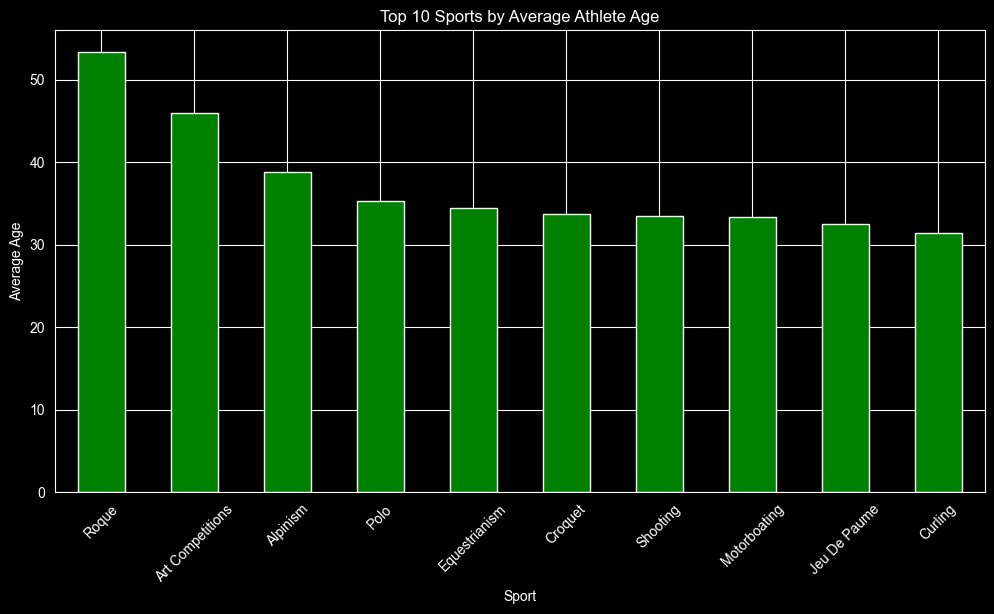

In [10]:
plt.figure(figsize=(12,6))
sport_ages.head(10).plot(kind='bar', color='green')
plt.title('Top 10 Sports by Average Athlete Age')
plt.xlabel('Sport')
plt.ylabel('Average Age')
plt.xticks(rotation=45)
plt.show()

In [5]:
most_gold_medals = df.groupby('Team')['Medal'].apply(lambda x: (x == 'Gold').sum()).sort_values(ascending=False)
print("\nTop 5 Teams by Gold Medals:")
print(most_gold_medals.head(5))


Top 5 Teams by Gold Medals:
Team
United States    2474
Soviet Union     1058
Germany           679
Italy             535
Great Britain     519
Name: Medal, dtype: int64


In [8]:
most_popular_romanian_sports = df[df['Team'] == 'Romania']['Sport'].value_counts().head(5)
print("\nTop 5 Most Popular Sports in Romania:")
print(most_popular_romanian_sports)


Top 5 Most Popular Sports in Romania:
Sport
Gymnastics    1172
Rowing         358
Athletics      325
Fencing        311
Canoeing       222
Name: count, dtype: int64


In [10]:
most_romanian_gold_medals = df[df['Team'] == 'Romania'].groupby('Sport')['Medal'].apply(lambda x: (x == 'Gold').sum()).sort_values(ascending=False)
print("\nTop 10 Sports in Romania by Gold Medals:")
print(most_romanian_gold_medals.head(10))


Top 5 Sports in Romania by Gold Medals:
Sport
Rowing           65
Gymnastics       40
Canoeing         18
Athletics        11
Fencing           7
Wrestling         7
Shooting          6
Swimming          3
Weightlifting     2
Judo              1
Name: Medal, dtype: int64


In [ ]:
plt.figure(figsize=(12,6))
most_romanian_gold_medals.head(10).plot(kind='bar', color='yellow')
plt.title('Top 10 Sports in Romania by Gold Medals')
plt.xlabel('Sport')
plt.ylabel('Medals')
plt.xticks(rotation=45)
plt.show()

In [19]:
romanian_gold_medals = df[(df['Team'] == 'Romania') & (df['Medal'] == 'Gold')]
result = romanian_gold_medals.groupby('Sport').apply(lambda x: x[['Year', 'Event']].drop_duplicates().shape[0]).sort_values(ascending=False)
print("\nTop 10 Romanian Gold Medals:")
print(result.head(10))


Top 10 Romanian Gold Medals:
Sport
Gymnastics       24
Rowing           19
Athletics        11
Canoeing         10
Wrestling         7
Shooting          6
Fencing           4
Swimming          3
Weightlifting     2
Boxing            1
dtype: int64


In [31]:
all_podium = df[df['Medal'].notna()].groupby(['Event', 'Year'])
result = all_podium.apply(lambda x: x['Team'].unique()[0] if x['Team'].nunique() == 1 else None).dropna()
print("\nTop 10 Swept Podium Finishes:")
print(result[result == True])


Top 10 Swept Podium Finishes:
Series([], dtype: str)
